<div class="alert alert-block alert-info">
¡Hola! Monica ¿cómo vas?

Mi nombre es SAntiago. Un gusto conocerte, seré tu revisor en este proyecto.

Cuando encuentre un error por primera vez, simplemente lo señalaré para que lo detectes y corrijas por tu cuenta. Si en la siguiente iteración no lograste resolverlo, te daré una pista más precisa con ejemplos. ¡También estoy disponible para cualquier duda que tengas!

Encontrarás mis comentarios a continuación: por favor, no los muevas, modifiques ni elimines.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b>

Éxito. Todo se ha hecho de forma correcta.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor.</b>

Observación. Algunas recomendaciones o mejoras menores.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor.</b>

Necesita arreglos. El trabajo no puede ser aceptado con comentarios rojos.
</div>

<div class="alert alert-block alert-info">
Puedes responder utilizando este formato:

Respuesta del estudiante.
</div>

<div class="alert alert-block alert-danger">
<b>Review General. (Iteración 1)</b> <a class="tocSkip"></a>

Antes de entrar en el detalle, quiero compartirte mis impresiones generales.

Hay cosas muy positivas: el MAR de `duration` y `length` está perfectamente verificado con `groupby(type).mean()` (el método correcto), la segmentación usa `if/elif/else` con los umbrales exactos, los countplots tienen `order=` para el orden lógico, los histogramas tienen `hue="plan"` con buenos insights, el IQR calcula el límite superior, y el insight ejecutivo tiene buena estructura con recomendaciones diferenciadas por segmento. ¡Buen trabajo en esos puntos!

Hay puntos que necesitan corrección antes de aprobar:

- **Diagnóstico de nulos (celda 16):** vacío — solo el template.
- **Cifras incorrectas (celda 23):** dice 31 registros con `?` en `city` cuando son 96.
- **Diagnóstico de fechas (celdas 31 y 34):** no menciona el año 2026 como el problema real.
- **Corrección de fechas (celda 38):** el filtro se aplica sobre `usage["date"]` en vez de `users["reg_date"]`. Los 40 del 2026 en `reg_date` nunca fueron corregidos.
- **GitHub:** el link tiene formato incorrecto.

¡Tienes buenas bases — son correcciones puntuales!

Saludos.
</div>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**:¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?



--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [81]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [82]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Imports y carga de datos correctos! ✅

Tip: agregar `import numpy as np` desde el inicio para tenerlo disponible cuando lo necesites.
</div>

In [83]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [84]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [85]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [86]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [87]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [88]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [89]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Bien verificando dimensiones con `.shape` e inspeccionando los tres datasets con `.info()`. ✅
</div>

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [90]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean().sort_values(ascending=False))

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
reg_date      0.00000
plan          0.00000
dtype: float64


In [91]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean().sort_values(ascending=False))


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
duration    0.55190
length      0.44740
date        0.00125
id          0.00000
user_id     0.00000
type        0.00000
dtype: float64


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Bien calculando nulos con `isna().sum()` e `isna().mean().sort_values()`. ✅
</div>


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- En el Data frame Users, la columna churn_date  tiene 88.5 % de valores nulos, lo que significa que son clientes activos, por lo tanto se deben conservar.
- En el data frame usages, la columna duration tiene 55.19 % de valores faltantes, se analizara mas adelante si corresponden a un MAR.
- La columna date, tiene 12% de valores nulos, y se convierten a NaT mas adelante.
- Indica qué harías: ¿imputar, eliminar, ignorar?
- La columna churn_date del df users la conservamos ya que representan clientes activospara.
- la columna duration y columna length se analizaran mas adelante para analizar si corresponden a MAR.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Esta celda quedó con solo el template sin completar. Por favor escribe tu diagnóstico:

- `churn_date` (88.35%): nulo = cliente activo → conservar.
- `city` (11.72%): nulos genuinos → conservar; además 96 `"?"` → reemplazar por `pd.NA`.
- `date` (0.12%): conservar como `NaT` — el evento sigue siendo válido.
- `duration` (55%) y `length` (45%): investigar si son MAR → ver Paso 3.2.
</div>

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [92]:
# explorar columnas numéricas de users
columnas_numericas= users.select_dtypes(include='number').describe()
print (columnas_numericas)

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` tiene un promedio de 11999, entre el valor minimo y maximo no existe mucha diferencia,
- La columna `age` tiene un valor minimo en negativo, lo que indica un error en carga de datos iniciales o captura ya que no existen edades negativas, este valor negativo esta afectando directamente el promedio de edad, por lo que se debe reemplazar los valores negativos con un NaN.

In [93]:
# explorar columnas numéricas de usage

columnas_numericas= usage.select_dtypes(include='number').describe()
print (columnas_numericas)


                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas id, muestra un registro total de 40000 registros, el registro del id va del valor 1(minimo) a 40000(maximo) que coincide con el numero total de registros. 
- la columna user_id tienen valores que van de 10000(minimo) a 14000(maximo).
- la relacion entre estas dos columnas id y user_id esta en que se tiene un numero total de registros de 40000 distribuidos entre 4000 usuarios, lo que da un promedio de 10 eventos por usuario.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Hay dos problemas en esta celda:

**1. Cifra incorrecta para el sentinel de `city`:** el diagnóstico dice "31 registros con `?`" pero el número real es **96 registros** (2.4%). Los 31 pueden ser el resultado de combinar `city` + `plan` en el `value_counts()` — la forma más clara es explorar `city` por sí sola:

```python
print(users["city"].value_counts(dropna=False))
```

**2. `value_counts()` sin `dropna=False`:** sin ese parámetro los nulos genuinos no aparecen en el output. Para ver el panorama completo (nulos + sentinel `"?"`) usa `dropna=False`.
</div>

In [94]:
# explorar columnas categóricas de users

print(users["city"].value_counts(dropna=False))



Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64


- La columna `city` se visualiza a la ciudad de Bogota como el que tiene mayor registroy se tiene 96 registros con sentinel ?

In [95]:
# explorar columna categórica de usage
columnas_usage=['type'] # completa el código
print(usage[columnas_usage].value_counts())

type
text    22092
call    17908
dtype: int64


- La columna `type` tiene 22092 registros como texto y solamente 17908 como call sumando un total de 40000 registros, lo que indica que en tipo los registros estan todos identificados como text o call.


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡La exploración de `type` confirma correctamente que solo tiene `call` y `text`! ✅
</div>

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
   1) columna age del Df users, el sentinel es -999, lo que se hara es reemplazar los sentinels -999 por NaN.
   2) columna city del Df users tiene sentinel ?, 96 registros por lo que se sustituye por NaN
- ¿Qué acción tomarías?
  En ambos casos y columnas sustituir los sentinels -999 y ? por NaN.
  

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

El diagnóstico identifica correctamente las dos columnas con sentinels. ✅

Dos ajustes de precisión:
1. Para `age`: el sentinel es `-999` específicamente (no solo "valores negativos"). Hay 55 registros exactos.
2. Para `city`: son **96 registros** con `"?"` (no 31) — ver comentario en celda 22.
</div>

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [96]:
# Convertir a fecha la columna `reg_date` de users
users["reg_date"] = pd.to_datetime(users["reg_date"], errors="coerce")

print(users['reg_date'])


0      2022-01-01 00:00:00.000000000
1      2022-01-01 06:34:17.914478619
2      2022-01-01 13:08:35.828957239
3      2022-01-01 19:42:53.743435858
4      2022-01-02 02:17:11.657914478
                    ...             
3995   2024-12-29 21:42:48.342085520
3996   2024-12-30 04:17:06.256564144
3997   2024-12-30 10:51:24.171042768
3998   2024-12-30 17:25:42.085521392
3999   2024-12-31 00:00:00.000000000
Name: reg_date, Length: 4000, dtype: datetime64[ns]


In [97]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce')
print(usage['date'])

0       2024-01-01 00:00:00.000000000
1       2024-01-01 00:06:30.969774244
2       2024-01-01 00:13:01.939548488
3       2024-01-01 00:19:32.909322733
4       2024-01-01 00:26:03.879096977
                     ...             
39995   2024-06-29 23:33:56.120903022
39996   2024-06-29 23:40:27.090677266
39997   2024-06-29 23:46:58.060451510
39998   2024-06-29 23:53:29.030225754
39999   2024-06-30 00:00:00.000000000
Name: date, Length: 40000, dtype: datetime64[ns]


<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Las conversiones a datetime funcionan en este dataset. ✅

Tip: agrega `errors="coerce"` para hacer el código robusto ante valores que no puedan convertirse (quedarán como `NaT` en lugar de generar error):

```python
users["reg_date"] = pd.to_datetime(users["reg_date"], errors="coerce")
```
</div>

In [98]:
# Revisar los años presentes en `reg_date` de users
conteo_users= users['reg_date'].dt.year.value_counts().sort_index()
print(conteo_users)

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Bien usando `value_counts().sort_index()` — puedes ver claramente los años presentes en `reg_date`. ✅
</div>

En `reg_date`2024 aparece 1330 veces, es el año que mayor veces aparece en el df users.
En el 2026 se tiene 40 registros, esto representa fechas imposibles den un dataset en donde la fecha de corte es a 2024.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

El diagnóstico menciona que 2024 aparece 1330 veces, pero **no menciona el año 2026** que es el problema real — hay **40 registros con año 2026** que son fechas imposibles en un dataset cuyo corte es 2024.

Por favor actualiza el diagnóstico para indicar esos 40 registros del 2026.
</div>

In [99]:
# Revisar los años presentes en `date` de usage
conteo_usage= usage['date'].dt.year.value_counts().sort_index()
print(conteo_usage)


2024.0    39950
Name: date, dtype: int64


En `date`,en el df usage solamente aparece el 2024 con registros, pero solamente cuenta 39950 que como vimos al inicio los 50 registros faltantes vienen desde el origen del DF.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- En el  caso del df users, aparece el año 2026 con 40 registros en reg_date que representan fechas futuras y se deben marcar como NaT.
-  En el df usage, los registros se concentran en el año 2024, y no se identifican los 50 faltantes a que año corresponderian.
  
- ¿Qué harías con ellas?

   A los registros faltantes de la columna reg_date en usage, se sustituirian por NaT, y los registros de df users sumando los años que aparecen suman el total de 4000 en la columna date.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

El diagnóstico dice "no aparece el año 2025", pero el problema no es el 2025 sino el **año 2026** — que sí aparece con 40 registros en `reg_date`. Son fechas futuras imposibles que deben marcarse como `pd.NaT`.

Por favor actualiza el diagnóstico para mencionar los 40 registros del 2026 y la acción: marcarlos como `pd.NaT` en `users["reg_date"]`.
</div>

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [100]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users["age"] != -999, "age"].median()


# Verificar cambios
nulos_age = users['age'].isna().sum()

print(f"Cantidad de valores nulos en 'age': {nulos_age}")

Cantidad de valores nulos en 'age': 0


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Correcto. Reemplazaste el sentinel `-999` por la mediana y `"?"` por `pd.NA`. ✅

Tip para `age`: la mediana se calcula incluyendo el `-999`, lo que la desplaza. Para ser más riguroso, exclúyelo antes:

```python
age_mediana = users.loc[users["age"] != -999, "age"].median()
```
</div>

In [101]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)


# Verificar cambios
nulos_city = users['city'].isna().sum()

print(f"Cantidad de valores nulos en 'city': {nulos_city}")

Cantidad de valores nulos en 'city': 565


In [102]:
# Marcar fechas futuras como NA para reg_date

users.loc[users["reg_date"].dt.year > 2024, "reg_date"] = pd.NaT


# Verificar cambios
users["reg_date"].dt.year.value_counts(dropna=False).sort_index()




2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Aquí hay un error importante. La celda aplica el filtro sobre `usage["date"]` en lugar de sobre `users["reg_date"]`:

```python
# Lo que hiciste (incorrecto — filtra usage["date"]):
condicion = usage["date"].dt.year > 2024
usage.loc[condicion, "date"] = pd.NaT
```

Pero el problema de los 40 registros del año 2026 está en **`users["reg_date"]`**, no en `usage["date"]`. El output lo confirma: `usage["date"].isna().sum()` retornó 50 (los nulos que ya existían), lo que significa que los 40 del 2026 en `reg_date` **nunca fueron corregidos**.

La corrección es:

```python
users.loc[users["reg_date"].dt.year > 2024, "reg_date"] = pd.NaT

# Verificar:
users["reg_date"].dt.year.value_counts(dropna=False).sort_index()
```
</div>

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [103]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)


type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [104]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)


type
call    0.99933
text    0.00000
Name: length, dtype: float64

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡MAR perfectamente verificado con `groupby(type).mean()`! Es el método correcto y el resultado confirma la relación estructural. ✅
</div>

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

La probabilidad de que falte un dato depende del tipo de registro (call o text). Esto confirma que la falta de datos es MAR (Missing At Random) y respalda la decisión de conservar esos valores como nulos NaN.
Para la columna length la rlacion con type call': La tasa de faltantes es del 99.93%. Si el registro es una llamada, el atributo de longitud de caracteres prácticamente no existe. Se deben mantener como nulos (NaN) porque la longitud en caracteres no aplica a una llamada telefónica.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Buen diagnóstico MAR! Bien justificado para `length`. ✅

Tip: completa el diagnóstico para `duration` también — su patrón es el inverso: 100% de nulos en registros de tipo `text` (no tiene sentido la duración en mensajes).
</div>

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [105]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

#aplicar filtro para quedarnos con informacion de 2024
usage_2024 = usage[usage['date'].dt.year == 2024]

# Agrupar información por usuario
usage_agg = usage_2024.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [106]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [107]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Agrupación con rename correcto y merge con `how="left"`! ✅

Nota: la celda 44 filtra `usage` al año 2024 antes de agregar. Esto excluye los 50 registros con `date` nula, que tienen eventos de uso válidos. Si la instrucción no pedía ese filtro, es mejor agrupar sobre `usage` completo.
</div>

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [108]:


# Resumen estadístico de las columnas numéricas
print("Resumen estadistico")
print()

user_profile[["age","cant_mensajes","cant_llamadas","cant_minutos_llamada"]].describe()



Resumen estadistico



,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,33.739750,5.518380,4.471618,23.288867
std,123.232257,2.358046,2.142878,18.161719
min,-999.000000,0.000000,0.000000,0.000000
25%,32.000000,4.000000,3.000000,11.085000
50%,47.000000,5.000000,4.000000,19.770000
75%,63.000000,7.000000,6.000000,31.355000
max,79.000000,17.000000,15.000000,155.690000


In [109]:
# Distribución porcentual del tipo de plan
print("Distribución porcentual del tipo de plan")
print()

print(user_profile['plan'].value_counts(normalize=True))



Distribución porcentual del tipo de plan

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

La distribución del plan con `normalize=True` es correcta. ✅

Tip: `user_profile.describe()` sin filtrar incluye `user_id` que no aporta información analítica. Filtra las 4 columnas relevantes:

```python
user_profile[["age","cant_mensajes","cant_llamadas","cant_minutos_llamada"]].describe()
```
</div>

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

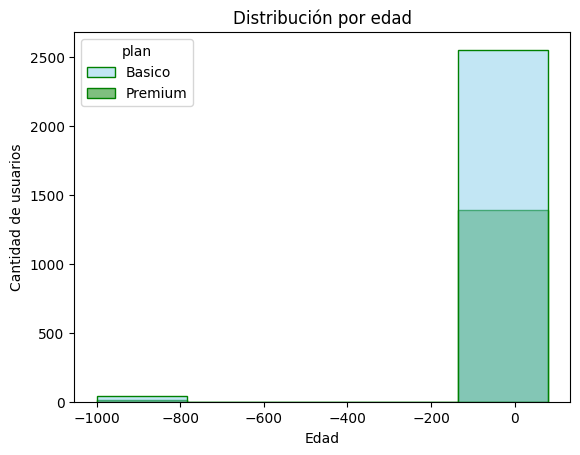

In [110]:


# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile, 
    x='age', 
    hue='plan',
    palette=['skyblue','green'],
    bins=5, 
    edgecolor='green',
    multiple='layer'  
)
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución por edad')
plt.show()




💡Insights: 
- Distribución; no se observa alguna concentracion en algun plan por edad, es decir no se visualiza que los jovenes tengan preferencia por algun tipo de plan y los adultos por otro. la distribucion es muy pareja, sin embargo por tipo de plan predomina mas el plan basico(barras azules) sobre el plan premium.

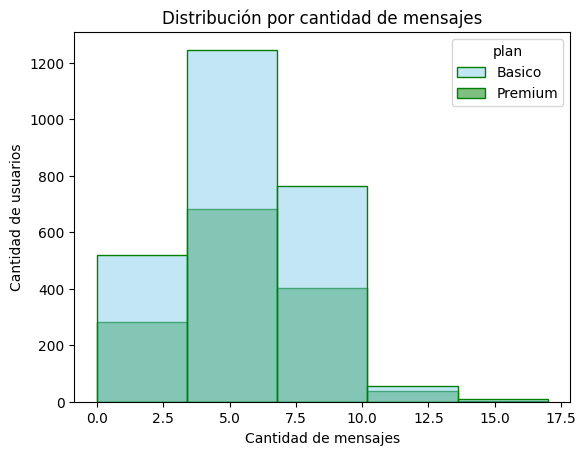

In [111]:


# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile, 
    x='cant_mensajes', 
    hue='plan',
    palette=['skyblue','green'],
    bins=5, 
    edgecolor='green',
    multiple='layer'  
)
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución por cantidad de mensajes')
plt.show()




💡Insights: 
- En la distribucion se observa un ligero sesgo hacia la derecha, ya que la mayoria de los usuaios manda una cantidad baja de mensajes, y muy pocos usuarios manda arriba de 12.5 mensajes.
- La mayoria de los usuarios aproximadamente 1250 manda entre 3 y 7 mensajes.

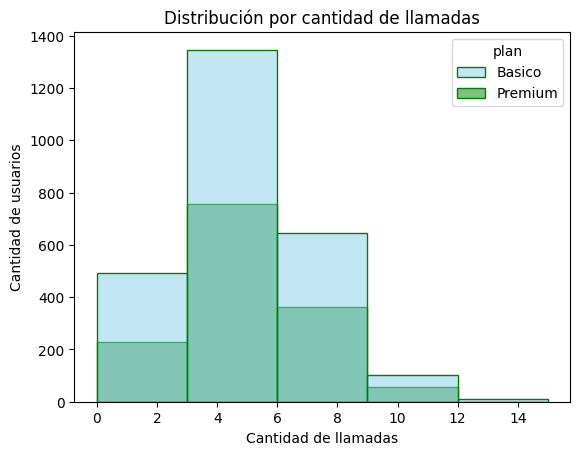

In [112]:


# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile, 
    x='cant_llamadas', 
    hue='plan',
    palette=['skyblue','green'],
    bins=5, 
    edgecolor='green',
    multiple='layer'  
)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución por cantidad de llamadas')


plt.show()


💡Insights: 
- Distribución; el rango modal, pico de uso de llamadas se concentra en 1350 usuarios en total, y este numero hace aproximadamente de 3 a 6 llamadas, los usuarios con el plan premium tienden ligeramente a realizar mas llamadas que los usuarios del plan basico en el rango modal.
- el numero de usuarios que realizan por arriba de 9 llamadas son la minoria en ambos planes.
  

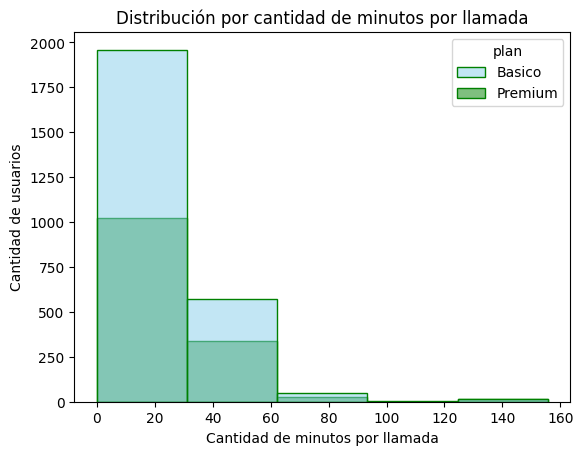

In [113]:


# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile, 
    x='cant_minutos_llamada', 
    hue='plan',
    palette=['skyblue','green'],
    bins=5, 
    edgecolor='green',
    multiple='layer'  
)
plt.xlabel('Cantidad de minutos por llamada')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución por cantidad de minutos por llamada')
plt.show()




💡Insights: 
- Existe una concentracion muy marcada en las llamadas cortas, por abajo de 30 min, y este corresponde al rango modal, la distribucion se encuentra sesgada a la derecha, es decir muy pocos usuarios hacern llamadas por arriba de los 60 minutos.
- Se observa poca diferencia con respecto al tipo de plan y el tiempo que los usuarios hablan por telefono, lo que nos indica que no tiene relacion el tipo de plan con el tiempo que se tardan los usuarios en llamadas.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Los cuatro histogramas tienen `hue="plan"`, títulos, etiquetas e insights bien redactados con observaciones de comportamiento por plan! ✅
</div>

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

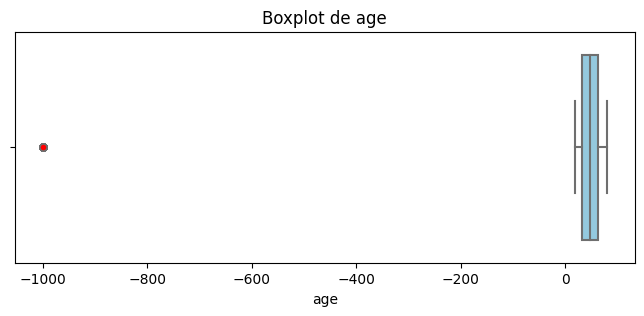

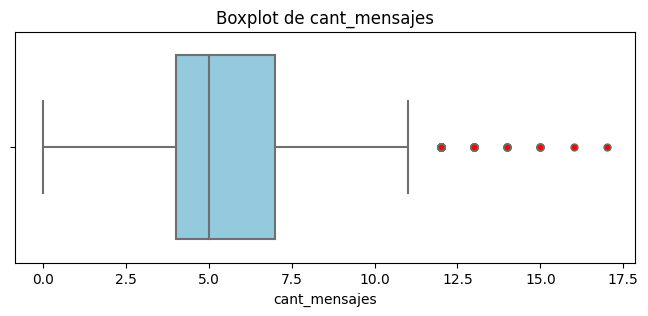

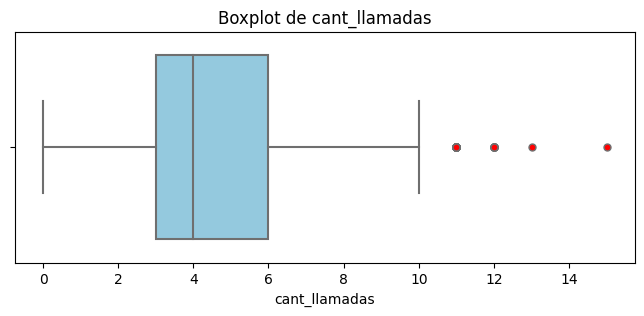

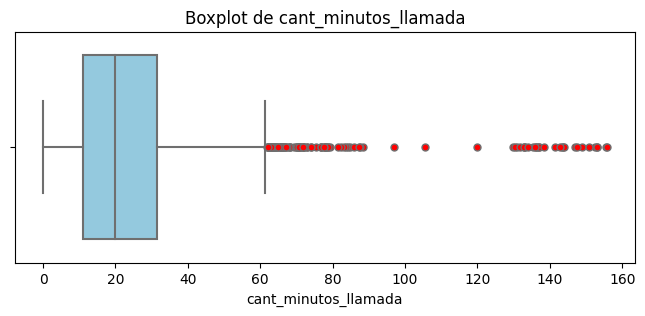

In [114]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_numericas:
    plt.figure(figsize=(8, 3))
    sns.boxplot(
        data=user_profile,
        x=col,
        color='skyblue',
        flierprops={'marker': 'o', 'markerfacecolor': 'red'},
    )
    plt.title(f'Boxplot de {col}')
    plt.show()



💡Insights: 
- Age: no presenta outliers, ya que se sustituyeron los valores negativos por la mediana.
- cant_mensajes: la distribución está sesgada a la derecha y los valores atípicos están únicamente por encima del límite superior.
- cant_llamadas: outliers a la derecha: Hay un par de puntos rojos atípicos por encima del límite de 10 llamadas (en valores como 11, 12, 13 y 15).
- cant_minutos_llamada: Todos los puntos rojos (valores atípicos) están por encima del bigote superior (62 minutos)

In [115]:



# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# Diccionario para almacenar los límites
limites_superiores = {}
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
   

    limites_superiores[col] = limite_superior
   

    print('Límites superiores calculados:')

for col, limite in limites_superiores.items():


        print(f' - {col}: {limite:.2f}')


Límites superiores calculados:
Límites superiores calculados:
Límites superiores calculados:
 - cant_mensajes: 11.50
 - cant_llamadas: 10.50
 - cant_minutos_llamada: 61.76


In [116]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.518380,4.471618,23.288867
std,2.358046,2.142878,18.161719
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.085000
50%,5.000000,4.000000,19.770000
75%,7.000000,6.000000,31.355000
max,17.000000,15.000000,155.690000


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡El IQR calcula el límite superior y los boxplots muestran claramente los outliers! ✅

Tip: calcula también el **límite inferior** para completar el análisis:

```python
limite_inferior = Q1 - 1.5 * IQR
```
</div>

💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
  No eliminar, porque el maximo es 17  que es un consumo real y viable,      eliminar estos usuarios reduciría el tamaño de la muestra y descartaría a los clientes más activos
- cant_llamadas: mantener o no outliers, porqué?
  No eliminar, conservar los datos, el registro de 11 a 15 llamadas es un dato real de uso intenso de algunos clientes.
- cant_minutos_llamada: mantener o no outliers, porqué?
  No eliminar, conservar porque las llamadas largas son un comportamiento atipico pero real de algunos clientes.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [117]:
# Crear columna grupo_uso
def categorizar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(categorizar_uso, axis=1)
print(user_profile['grupo_uso'].value_counts())


Uso medio    2941
Bajo uso      780
Alto uso      279
Name: grupo_uso, dtype: int64


In [118]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [123]:
# Crear columna grupo_edad
# Asignar 'Joven'
user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'

# Asignar 'Adulto' (mayor o igual a 30 Y menor a 60)
user_profile.loc[(user_profile['age'] >= 30) & (user_profile['age'] < 60), 'grupo_edad'] = 'Adulto'

# Asignar 'Adulto Mayor' al resto
user_profile.loc[user_profile['age'] >= 60, 'grupo_edad'] = 'Adulto Mayor'

# Verificar la distribución
print(user_profile['grupo_edad'].value_counts())

Adulto          1963
Adulto Mayor    1222
Joven            815
Name: grupo_edad, dtype: int64


In [124]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

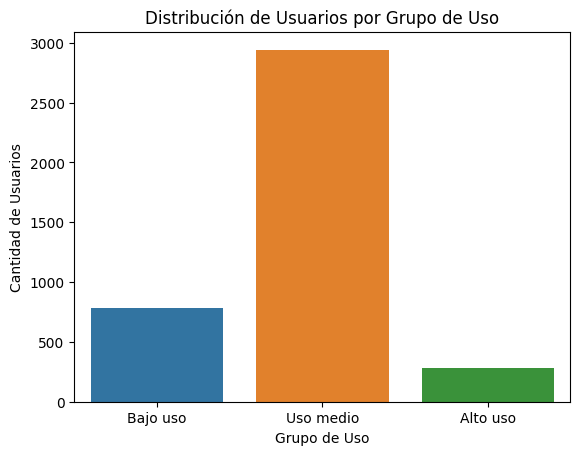

In [121]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso'],
)

plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()

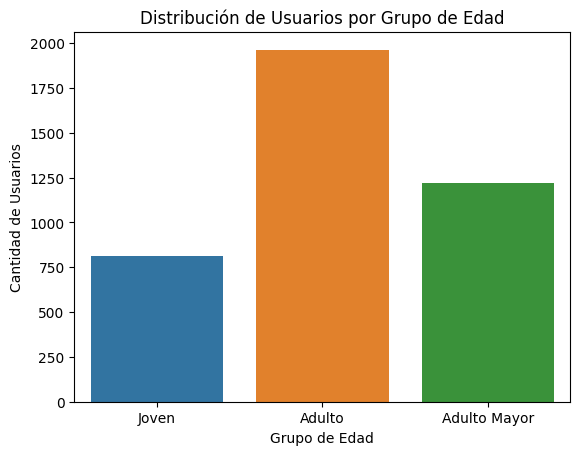

In [122]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor'],
)

plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()



<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Funciones de segmentación correctas, `.loc[]` para `grupo_edad` (también válido), y countplots con `order=` para el orden lógico! ✅
</div>


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

-Archivo users_latam.csv (Total: 40,000 filas)
  •En el archivo original users_latam.csv, se tenian columna city faltaban datos, 469 filas representando el 11.72%.

  •En archivo users_latam.csv ausencia de fecha de baja en churn_date:3,534 filas (88.35%) nulas.

  •Las columnas reg_date y churn_date están almacenadas como texto (object/string) en lugar de tipo fecha (datetime).

Archivo usage.csv (Total: 40,000 filas)

  •Valores nulos en la fecha (date): Cantidad 50 filas.

  •La columna date está guardada como texto (object/string) en lugar de tipo fecha (datetime)

  •La columna duration tiene 22,076 nulos (55.19%) porque corresponde a mensajes (text).

  •La columna length tiene 17,896 nulos.

  •La columna city tiene 96 sentinels, que se tienen que sustituir por NaN.

  •En la columna reg_date, se tienen 40 registros correspondientes al año 2026, estos no se pueden analizar asi que se convierten a tipo NaT
  


🔍 **Segmentos por Edad**
- Predominio del Segmento Adulto: La mitad de la base de usuarios se concentra en el grupo de Adulto, convirtiéndolo en el mercado objetivo para la retención y venta de planes.
- Representación Relevante de Adultos Mayores: Constituyen más del 30% de los clientes, un porcentaje significativamente mayor que el grupo Joven


📊 **Segmentos por Nivel de Uso**
- aproximadamente un 75% de los clientes se ubican en la categoría de Uso medio, mostrando un consumo regular
- Segmento de Bajo Uso 19.8% realiza muy pocos eventos. Este segmento representa un riesgo.
- usuario alto uso representa el 7.0% de la base. Son los candidatos perfectos para ventas de planes Premium


➡️ Esto sugiere que Las características y beneficios de los planes deben alinearse con las necesidades de un público con mayor madurez de edad


💡 **Recomendaciones**
Por grupo de edad:
- Jóvenes tienen alta afinidad por la conectividad digital se puede buscar la fidelizacion con estrategias enfocadas a los beneficios digitales y de datos.
- Adultos Mayores;Un grupo numeroso (30%) que prioriza la simplicidad, ofrecer atención prioritaria y humana
Por Grupo de uso:
- Bajo Uso; Campañas de Engagement enviar recordatorios con los beneficios disponibles de su plan que aún no han utilizado
- Ajuste de Tarifa crear una opción de plan reducido para evitar que abandonen la compañía por completo.
- Uso Medio aplicar programas de recompensas
- Alto uso, migracion a planes premium.
  

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Insight ejecutivo con buena estructura! Problemas detectados, segmentos descriptos y recomendaciones diferenciadas por segmento de edad y uso. ✅

Tip para enriquecerlo: agrega los conteos exactos de cada segmento (ya los tienes en las celdas 66 y 69) y menciona el sentinel de `"?"` en `city` y los 40 del 2026 en `reg_date` entre los problemas detectados.
</div>

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: https://github.com/chanlucytamg-cmd/sprint7-final-project-